# ICU Energy Analysis v1 — MIMIC-IV & eICU
## Research: ICU Monitor Energy Optimization
**Author:** Konstantinos Dinos Kritsis  
**Date:** April 2026

In this notebook I carry out the complete energy analysis pipeline for my research. 
Building on the exploration and cleaning work I completed in my previous notebooks, 
here I focus on:

- Corrected CO2 factors — I use the Massachusetts/NEWE subregion factor for MIMIC-IV 
  and the US national average for eICU, both from EPA eGRID 2023
- Energy calculations using two monitor types — Philips X3+M750 and GE CARESCAPE ONE
- K-means clustering to identify patient monitoring waste profiles — the ML component
- Energy simulation per cluster showing savings per patient archetype
- A cross-dataset comparison between MIMIC-IV and eICU results

### Visualisations I Will Explore in This Notebook
As part of this analysis I will build and compare five different types of 
visualisations to communicate my findings:

1. **Time-of-Day Histogram** — hours on X axis, idle percentage on Y axis, 
   showing when monitor waste peaks across the day
2. **ICU Unit Type Bar Chart** — comparing idle percentage and wasted energy 
   across different ICU unit types
3. **Energy Comparison Chart** — side by side Philips vs GE energy results 
   across both datasets
4. **K-means Cluster Scatter Plot** — each patient stay plotted by length of 
   stay and idle percentage, coloured by cluster
5. **Cluster Energy Savings Bar Chart** — potential energy saving per cluster, 
   showing which patient archetype has the highest saving potential
   

In [1]:
# I import all libraries I will need for this analysis upfront
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries loaded successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


## My Constants — Power Figures and CO2 Factors

### Monitor Power Figures I Am Using

**Philips X3 + M750** — the only peer-reviewed measured values available:
- Operating: 34.8W
- Standby: 30.5W (87.6% of operating power)
- Source: Drinhaus et al. (2023), physically measured in a real ICU environment
- Link: https://pmc.ncbi.nlm.nih.gov/articles/PMC10119198/

**GE CARESCAPE ONE** — no peer-reviewed measurement exists for this device.
I conduct a sensitivity analysis using three power assumptions:
- Optimistic: 20W (low end estimate for bedside operation)
- Moderate: 40W (midpoint between transport mode and maximum rated output)
- Conservative: 60W (maximum dock output from official GE datasheet 2023)
- The battery capacity method gives ~14W in transport mode, but this 
  underestimates real bedside consumption since it excludes battery charging 
  and full display brightness. I therefore treat 14W as a lower bound only.
- Source: GE Healthcare CARESCAPE ONE official datasheet (2023)

### CO2 Emission Factors I Am Using
I updated my CO2 factors following feedback from my supervisor to use 
US-specific figures rather than the European average I originally used:
- **MIMIC-IV:** 0.245 kg CO2/kWh — EPA eGRID 2023 NEWE subregion 
  (New England, covering Massachusetts where MIMIC was collected)
- **eICU:** 0.348 kg CO2/kWh — EPA eGRID 2023 US national average 
  (appropriate since eICU spans 208 hospitals across the US)
- **Source:** EPA eGRID2023 Summary Tables, released January 2025
- https://www.epa.gov/egrid/summary-data

In [8]:
# ── Philips X3 + M750 — peer reviewed measurement (Drinhaus et al. 2023) ──
PHILIPS_OPERATING = 0.0348   # kW — 34.8W operating
PHILIPS_STANDBY   = 0.0305   # kW — 30.5W standby
PHILIPS_RATIO     = PHILIPS_STANDBY / PHILIPS_OPERATING  # 87.6%

# ── GE CARESCAPE ONE — sensitivity analysis (no peer reviewed measurement) ──
GE_OPTIMISTIC     = 0.0200   # kW — 20W optimistic estimate
GE_MODERATE       = 0.0400   # kW — 40W moderate estimate
GE_CONSERVATIVE   = 0.0600   # kW — 60W maximum rated (GE datasheet 2023)

# GE standby estimated using Philips ratio as best available approximation
GE_STANDBY_OPT    = GE_OPTIMISTIC    * PHILIPS_RATIO  # ~17.5W
GE_STANDBY_MOD    = GE_MODERATE      * PHILIPS_RATIO  # ~35W
GE_STANDBY_CON    = GE_CONSERVATIVE  * PHILIPS_RATIO  # ~52.6W

# ── CO2 Emission Factors — EPA eGRID 2023 ─────────────────────────────────
CO2_MIMIC = 0.245   # kg CO2/kWh — NEWE subregion (Massachusetts)
CO2_EICU  = 0.348   # kg CO2/kWh — US national average

print("=== Constants Loaded Successfully ===")
print(f"\nPhilips X3+M750 (peer reviewed):")
print(f"  Operating:          {PHILIPS_OPERATING*1000:.1f}W")
print(f"  Standby:            {PHILIPS_STANDBY*1000:.1f}W")
print(f"  Standby/Operating:  {PHILIPS_RATIO*100:.1f}%")
print(f"\nGE CARESCAPE ONE (sensitivity analysis):")
print(f"  Optimistic:         {GE_OPTIMISTIC*1000:.1f}W")
print(f"  Moderate:           {GE_MODERATE*1000:.1f}W")
print(f"  Conservative:       {GE_CONSERVATIVE*1000:.1f}W")
print(f"\nCO2 emission factors:")
print(f"  MIMIC-IV (MA/NEWE): {CO2_MIMIC} kg/kWh")
print(f"  eICU (US national): {CO2_EICU} kg/kWh")

=== Constants Loaded Successfully ===

Philips X3+M750 (peer reviewed):
  Operating:          34.8W
  Standby:            30.5W
  Standby/Operating:  87.6%

GE CARESCAPE ONE (sensitivity analysis):
  Optimistic:         20.0W
  Moderate:           40.0W
  Conservative:       60.0W

CO2 emission factors:
  MIMIC-IV (MA/NEWE): 0.245 kg/kWh
  eICU (US national): 0.348 kg/kWh


## Step 1 — Loading My Data Files

I load the pre-processed files I saved in my previous analysis notebook.
This avoids having to re-run the heavy filtering and timeline building steps.
The files I need are:
- stay_summary.csv.gz — MIMIC-IV stay-level summary with active/idle hours already calculated
- icustays.csv.gz — MIMIC-IV stay metadata including ICU unit type
- monitor_events_filtered.csv.gz — MIMIC-IV filtered monitor events for time-of-day analysis
- patient.csv.gz — eICU patient file for the eICU energy analysis
- vitalPeriodic.csv.gz — eICU vital signs for the eICU activity timeline

In [3]:
# I load the MIMIC-IV pre-processed files
print("Loading MIMIC-IV files...")

# Stay summary — already has active and idle hours calculated
stay_summary = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/stay_summary.csv.gz',
    compression='gzip'
)

# ICU stays — for unit type and metadata
df_icustays = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/icustays.csv.gz',
    compression='gzip'
)

# Filtered monitor events — for time of day analysis
df_monitor_events = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/monitor_events_filtered.csv.gz',
    compression='gzip',
    parse_dates=['charttime']
)

print("=== MIMIC-IV Files Loaded ===")
print(f"Stay summary:      {len(stay_summary):,} stays")
print(f"ICU stays:         {len(df_icustays):,} stays")
print(f"Monitor events:    {len(df_monitor_events):,} rows")

Loading MIMIC-IV files...
=== MIMIC-IV Files Loaded ===
Stay summary:      93,730 stays
ICU stays:         94,458 stays
Monitor events:    53,806,854 rows


In [4]:
# I load the eICU files needed for the analysis
print("Loading eICU files...")

# Patient file — stay metadata and length of stay
df_patient = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/patient.csv.gz',
    compression='gzip'
)

# Clean eICU patient file — remove negative LOS and stays under 4 hours
df_patient['los_hours'] = df_patient['unitdischargeoffset'] / 60
df_patient_clean = df_patient[df_patient['los_hours'] >= 0].copy()
df_patient_clean = df_patient_clean[df_patient_clean['los_hours'] >= 4].copy()

print("=== eICU Files Loaded ===")
print(f"Original patient stays:      {len(df_patient):,}")
print(f"Cleaned patient stays:       {len(df_patient_clean):,}")
print(f"Records removed:             {len(df_patient) - len(df_patient_clean):,}")

Loading eICU files...
=== eICU Files Loaded ===
Original patient stays:      200,859
Cleaned patient stays:       188,789
Records removed:             12,070


## Step 2 — Building the eICU Activity Timeline

I build the hourly activity timeline for eICU using vitalPeriodic — the file 
recorded automatically by the monitoring system at 5-minute intervals through 
the Philips eICU telehealth platform. I use heartrate and sao2 as my activity 
signals since they are the most consistently recorded columns (99.5% and 90.6% 
present respectively across 146 million rows).

I convert observationoffset from minutes to hours to create an hourly timeline 
comparable to the one I built for MIMIC-IV.

In [5]:
# I build the eICU hourly activity timeline from vitalPeriodic
print("Loading vitalPeriodic — this will take a few minutes...")

df_periodic = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/vitalPeriodic.csv.gz',
    compression='gzip',
    usecols=['patientunitstayid', 'observationoffset', 'heartrate', 'sao2']
)

print(f"Loaded: {len(df_periodic):,} rows")

# I remove rows with no heartrate or sao2 — no activity signal
df_periodic = df_periodic.dropna(subset=['heartrate', 'sao2'], how='all')
print(f"After removing rows with no activity signal: {len(df_periodic):,}")

# I remove negative offsets
df_periodic = df_periodic[df_periodic['observationoffset'] >= 0]
print(f"After removing negative offsets: {len(df_periodic):,}")

# I convert offset minutes to hours
df_periodic['hour_offset'] = (df_periodic['observationoffset'] // 60).astype(int)

# I get one row per stay per hour — active hours
active_hours_eicu = df_periodic.groupby(
    ['patientunitstayid', 'hour_offset']
).size().reset_index(name='event_count')

active_hours_eicu['status'] = 'ACTIVE'

print(f"\n=== eICU Activity Timeline Built ===")
print(f"Total ACTIVE monitor hours: {len(active_hours_eicu):,}")
print(f"Unique stays with activity: {active_hours_eicu['patientunitstayid'].nunique():,}")
print(f"\nFirst 5 rows:")
active_hours_eicu.head()

Loading vitalPeriodic — this will take a few minutes...
Loaded: 146,671,642 rows
After removing rows with no activity signal: 146,575,663
After removing negative offsets: 146,446,254

=== eICU Activity Timeline Built ===
Total ACTIVE monitor hours: 12,466,089
Unique stays with activity: 192,706

First 5 rows:


,patientunitstayid,hour_offset,event_count,status
0,141168,1,1,ACTIVE
1,141168,2,12,ACTIVE
2,141168,3,12,ACTIVE
3,141168,4,12,ACTIVE
4,141168,5,12,ACTIVE


## Step 3 — Calculating eICU Idle Hours

I calculate the total occupied hours, active hours, and idle hours for each 
eICU stay. I then merge this with the cleaned patient file to get the full 
stay summary including ICU unit type and length of stay.

In [6]:
# I calculate active hours per stay
active_per_stay_eicu = active_hours_eicu.groupby(
    'patientunitstayid'
).size().reset_index(name='active_hours')

# I merge with cleaned patient file
stay_summary_eicu = df_patient_clean.merge(
    active_per_stay_eicu,
    on='patientunitstayid',
    how='left'
)

# I fill stays with no activity as 0 active hours
stay_summary_eicu['active_hours'] = stay_summary_eicu['active_hours'].fillna(0)

# I calculate total hours and idle hours
stay_summary_eicu['total_hours'] = stay_summary_eicu['los_hours'].round().astype(int)
stay_summary_eicu['idle_hours'] = (
    stay_summary_eicu['total_hours'] - stay_summary_eicu['active_hours']
).clip(lower=0)

print("=== eICU Stay Summary ===")
print(f"Total stays:          {len(stay_summary_eicu):,}")
print(f"Total occupied hours: {stay_summary_eicu['total_hours'].sum():,}")
print(f"Total ACTIVE hours:   {stay_summary_eicu['active_hours'].sum():,.0f}")
print(f"Total IDLE hours:     {stay_summary_eicu['idle_hours'].sum():,.0f}")

active_pct = stay_summary_eicu['active_hours'].sum() / stay_summary_eicu['total_hours'].sum() * 100
idle_pct = stay_summary_eicu['idle_hours'].sum() / stay_summary_eicu['total_hours'].sum() * 100

print(f"\nACTIVE: {active_pct:.1f}% of all occupied hours")
print(f"IDLE:   {idle_pct:.1f}% of all occupied hours")

=== eICU Stay Summary ===
Total stays:          188,789
Total occupied hours: 12,896,534
Total ACTIVE hours:   12,441,216
Total IDLE hours:     524,031

ACTIVE: 96.5% of all occupied hours
IDLE:   4.1% of all occupied hours


## Step 4 — Energy Analysis

I calculate energy consumption and CO2 emissions for both datasets using:
- Philips X3+M750 as the primary monitor (peer-reviewed measured values)
- GE CARESCAPE ONE as a sensitivity analysis under three power assumptions

For each scenario I calculate:
- Baseline energy — monitor at full power for all occupied hours
- Wasted energy — idle hours at full power
- Saveable energy — potential saving switching to standby during idle hours
- CO2 equivalent for each figure

I use dataset-specific CO2 factors from EPA eGRID 2023:
- MIMIC-IV: 0.245 kg CO2/kWh — Massachusetts/NEWE subregion
- eICU: 0.348 kg CO2/kWh — US national average

In [9]:
# I define a reusable energy analysis function
def energy_analysis(total_hours, idle_hours, power_operating,
                    power_standby, co2_factor, label):
    baseline_kwh = total_hours * power_operating
    wasted_kwh   = idle_hours * power_operating
    saveable_kwh = idle_hours * (power_operating - power_standby)
    saving_pct   = saveable_kwh / baseline_kwh * 100
    baseline_co2 = baseline_kwh * co2_factor
    wasted_co2   = wasted_kwh * co2_factor
    saveable_co2 = saveable_kwh * co2_factor

    print(f"\n{'='*58}")
    print(f"{label}")
    print(f"{'='*58}")
    print(f"  Baseline energy:  {baseline_kwh:>12,.0f} kWh")
    print(f"  Wasted energy:    {wasted_kwh:>12,.0f} kWh")
    print(f"  Saveable energy:  {saveable_kwh:>12,.0f} kWh ({saving_pct:.1f}%)")
    print(f"  Baseline CO2:     {baseline_co2:>12,.0f} kg")
    print(f"  Wasted CO2:       {wasted_co2:>12,.0f} kg")
    print(f"  Saveable CO2:     {saveable_co2:>12,.0f} kg")

    return {
        'label': label,
        'baseline_kwh': baseline_kwh,
        'wasted_kwh': wasted_kwh,
        'saveable_kwh': saveable_kwh,
        'saving_pct': saving_pct,
        'baseline_co2': baseline_co2,
        'wasted_co2': wasted_co2,
        'saveable_co2': saveable_co2
    }

# I get total and idle hours for each dataset
mimic_total = stay_summary['total_hours'].sum()
mimic_idle  = stay_summary['idle_hours'].sum()
eicu_total  = stay_summary_eicu['total_hours'].sum()
eicu_idle   = stay_summary_eicu['idle_hours'].sum()

print("=== PRIMARY ANALYSIS — PHILIPS X3+M750 (PEER REVIEWED) ===")
r_mimic_philips = energy_analysis(
    mimic_total, mimic_idle,
    PHILIPS_OPERATING, PHILIPS_STANDBY,
    CO2_MIMIC, "MIMIC-IV — Philips X3+M750 (34.8W measured)"
)
r_eicu_philips = energy_analysis(
    eicu_total, eicu_idle,
    PHILIPS_OPERATING, PHILIPS_STANDBY,
    CO2_EICU, "eICU — Philips X3+M750 (34.8W measured)"
)

print("\n\n=== SENSITIVITY ANALYSIS — GE CARESCAPE ONE ===")
print("(No peer-reviewed measurement — three assumptions used)")

r_mimic_ge_opt = energy_analysis(
    mimic_total, mimic_idle,
    GE_OPTIMISTIC, GE_STANDBY_OPT,
    CO2_MIMIC, "MIMIC-IV — GE CARESCAPE ONE (20W optimistic)"
)
r_mimic_ge_mod = energy_analysis(
    mimic_total, mimic_idle,
    GE_MODERATE, GE_STANDBY_MOD,
    CO2_MIMIC, "MIMIC-IV — GE CARESCAPE ONE (40W moderate)"
)
r_mimic_ge_con = energy_analysis(
    mimic_total, mimic_idle,
    GE_CONSERVATIVE, GE_STANDBY_CON,
    CO2_MIMIC, "MIMIC-IV — GE CARESCAPE ONE (60W conservative)"
)

r_eicu_ge_opt = energy_analysis(
    eicu_total, eicu_idle,
    GE_OPTIMISTIC, GE_STANDBY_OPT,
    CO2_EICU, "eICU — GE CARESCAPE ONE (20W optimistic)"
)
r_eicu_ge_mod = energy_analysis(
    eicu_total, eicu_idle,
    GE_MODERATE, GE_STANDBY_MOD,
    CO2_EICU, "eICU — GE CARESCAPE ONE (40W moderate)"
)
r_eicu_ge_con = energy_analysis(
    eicu_total, eicu_idle,
    GE_CONSERVATIVE, GE_STANDBY_CON,
    CO2_EICU, "eICU — GE CARESCAPE ONE (60W conservative)"
)

# Store all results for visualisation
results = [
    r_mimic_philips, r_eicu_philips,
    r_mimic_ge_opt, r_mimic_ge_mod, r_mimic_ge_con,
    r_eicu_ge_opt, r_eicu_ge_mod, r_eicu_ge_con
]
print("\n\nAll energy calculations complete!")

=== PRIMARY ANALYSIS — PHILIPS X3+M750 (PEER REVIEWED) ===

MIMIC-IV — Philips X3+M750 (34.8W measured)
  Baseline energy:       286,277 kWh
  Wasted energy:          11,221 kWh
  Saveable energy:         1,386 kWh (0.5%)
  Baseline CO2:           70,138 kg
  Wasted CO2:              2,749 kg
  Saveable CO2:              340 kg

eICU — Philips X3+M750 (34.8W measured)
  Baseline energy:       448,799 kWh
  Wasted energy:          18,236 kWh
  Saveable energy:         2,253 kWh (0.5%)
  Baseline CO2:          156,182 kg
  Wasted CO2:              6,346 kg
  Saveable CO2:              784 kg


=== SENSITIVITY ANALYSIS — GE CARESCAPE ONE ===
(No peer-reviewed measurement — three assumptions used)

MIMIC-IV — GE CARESCAPE ONE (20W optimistic)
  Baseline energy:       164,527 kWh
  Wasted energy:           6,449 kWh
  Saveable energy:           797 kWh (0.5%)
  Baseline CO2:           40,309 kg
  Wasted CO2:              1,580 kg
  Saveable CO2:              195 kg

MIMIC-IV — GE CARESCAPE 

## Visualisation 1 — Time-of-Day Idle Pattern Histogram

I create a histogram showing the estimated idle percentage for each hour of 
the day across MIMIC-IV. This visualisation was specifically requested by my 
supervisor Timo to make the time-of-day findings more readable and impactful.
Red bars highlight hours where idle percentage exceeds 5% — the periods where 
monitor energy waste is highest.

In [12]:
# Visualisation 1 — Time of Day (fast corrected version)

# I add hour of day and floor hour to monitor events
df_monitor_events['hour_of_day'] = df_monitor_events['charttime'].dt.hour
df_monitor_events['hour_floor'] = df_monitor_events['charttime'].dt.floor('h')

# I get unique stay-hour combinations (one row per stay per hour)
active_stay_hours = df_monitor_events.groupby(
    ['stay_id', 'hour_floor', 'hour_of_day']
).size().reset_index(name='count')

# I count how many active stay-hours fall in each hour of day
active_by_hour = active_stay_hours.groupby(
    'hour_of_day'
)['stay_id'].count().reset_index(name='active_hours')

# Total occupied hours per slot
total_per_slot = stay_summary['total_hours'].sum() / 24

# Calculate idle percentage
active_by_hour['idle_pct'] = (
    (total_per_slot - active_by_hour['active_hours']) / total_per_slot * 100
).clip(lower=0)

print("Hour of day idle percentages:")
print(active_by_hour[['hour_of_day', 'active_hours', 'idle_pct']].to_string())

Hour of day idle percentages:
    hour_of_day  active_hours  idle_pct
0             0        329280  3.934030
1             1        322931  5.786323
2             2        331656  3.240843
3             3        327882  4.341891
4             4        338673  1.193665
5             5        331130  3.394301
6             6        333498  2.703448
7             7        328718  4.097991
8             8        343175  0.000000
9             9        333740  2.632845
10           10        340588  0.634972
11           11        334855  2.307549
12           12        344495  0.000000
13           13        334079  2.533944
14           14        339339  0.999362
15           15        330961  3.443606
16           16        336767  1.749732
17           17        323270  5.687421
18           18        319063  6.914795
19           19        313759  8.462213
20           20        327971  4.315925
21           21        318094  7.197496
22           22        323653  5.575683
23        

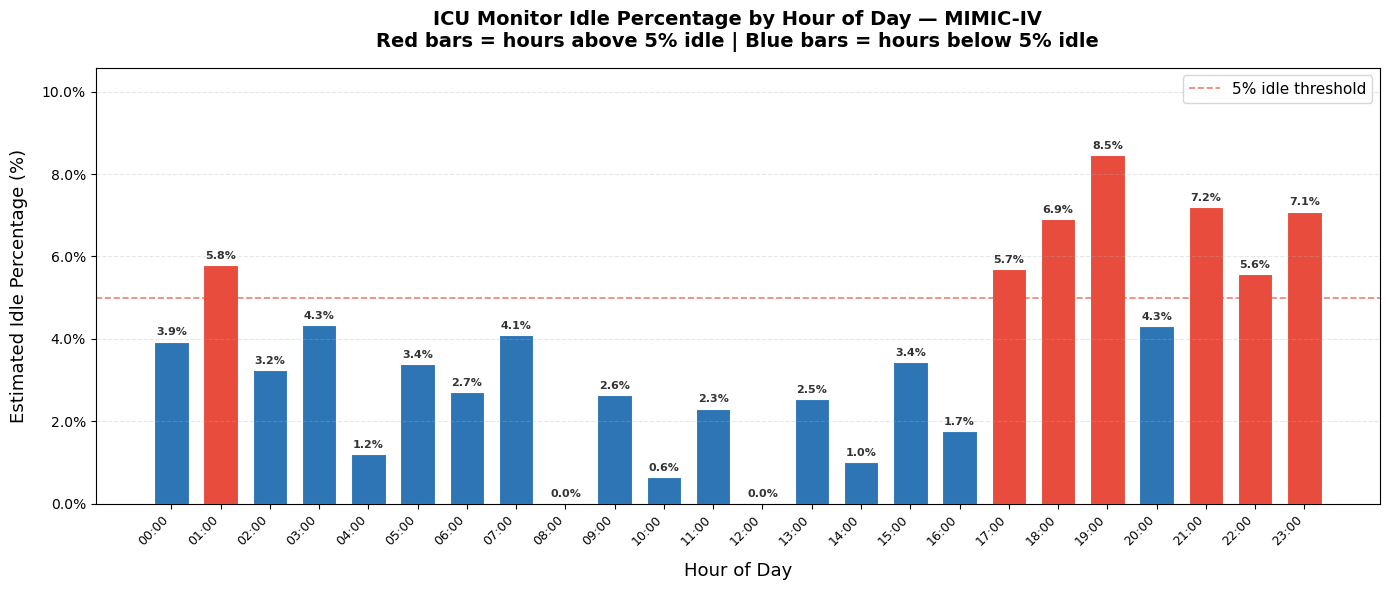

Visualisation 1 saved to Desktop!


In [13]:
# I now plot the corrected time of day histogram
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#E74C3C' if x >= 5 else '#2E75B6'
          for x in active_by_hour['idle_pct']]

bars = ax.bar(
    active_by_hour['hour_of_day'],
    active_by_hour['idle_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.7
)

# I add value labels on top of each bar
for bar, val in zip(bars, active_by_hour['idle_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=8, fontweight='bold',
        color='#333333'
    )

# I add a 5% reference line
ax.axhline(y=5, color='#E74C3C', linestyle='--',
           linewidth=1.2, alpha=0.7, label='5% idle threshold')

ax.set_xlabel('Hour of Day', fontsize=13, labelpad=10)
ax.set_ylabel('Estimated Idle Percentage (%)', fontsize=13, labelpad=10)
ax.set_title(
    'ICU Monitor Idle Percentage by Hour of Day — MIMIC-IV\n'
    'Red bars = hours above 5% idle | Blue bars = hours below 5% idle',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xticks(range(24))
ax.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, ha='right', fontsize=9
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(active_by_hour['idle_pct']) * 1.25)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz1_time_of_day_histogram.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Visualisation 1 saved to Desktop!")

## Visualisation 2 — ICU Unit Type Energy Waste Bar Chart

I create a bar chart showing the idle percentage and wasted energy broken down 
by ICU unit type across MIMIC-IV. This visualisation highlights which units 
waste the most monitor energy — one of the most clinically interesting findings 
in my research. I sort by idle percentage to make the ranking immediately clear.

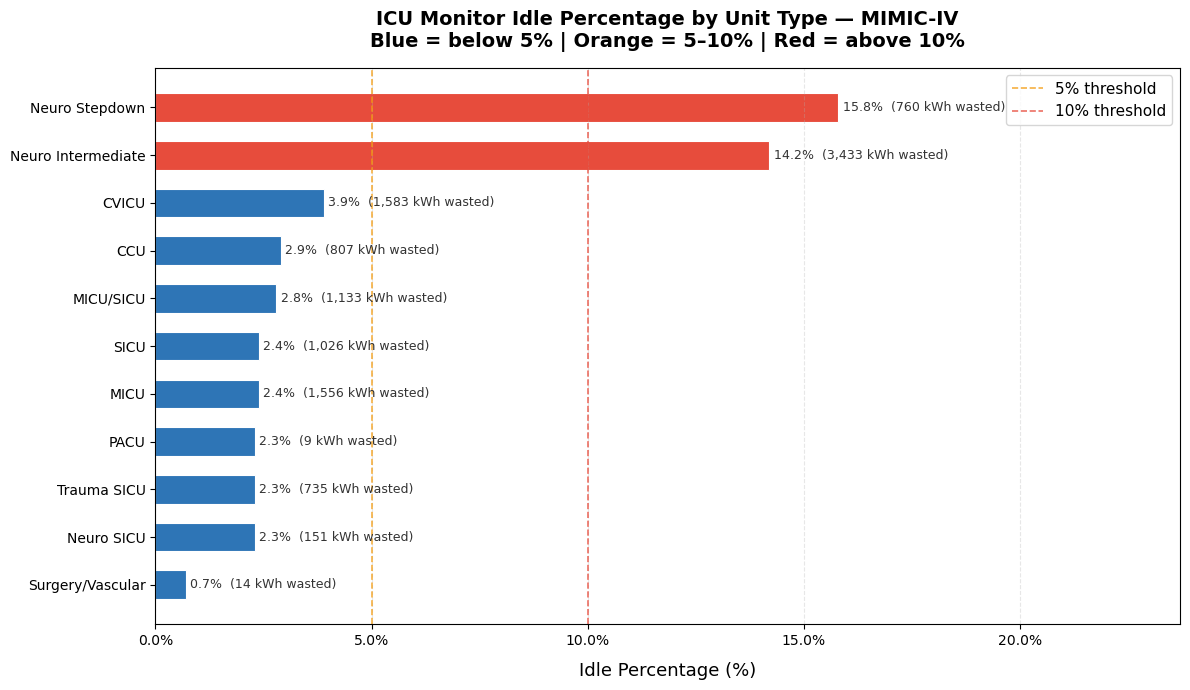

Visualisation 2 saved to Desktop!


In [14]:
# Visualisation 2 — ICU Unit Type Idle Percentage Bar Chart

# I calculate idle stats per ICU unit type
unit_summary = stay_summary.groupby('first_careunit').agg(
    total_stays=('stay_id', 'count'),
    total_hours=('total_hours', 'sum'),
    active_hours=('active_hours', 'sum'),
    idle_hours=('idle_hours', 'sum')
).reset_index()

# I calculate idle percentage and wasted energy per unit
unit_summary['idle_pct'] = (
    unit_summary['idle_hours'] / unit_summary['total_hours'] * 100
).round(1)
unit_summary['wasted_kwh'] = (
    unit_summary['idle_hours'] * PHILIPS_OPERATING
).round(0)

# I remove very small units (under 50 stays) for cleaner chart
unit_summary = unit_summary[unit_summary['total_stays'] >= 50]

# I sort by idle percentage descending
unit_summary = unit_summary.sort_values('idle_pct', ascending=True)

# I shorten long unit names for readability
name_map = {
    'Medical Intensive Care Unit (MICU)': 'MICU',
    'Medical/Surgical Intensive Care Unit (MICU/SICU)': 'MICU/SICU',
    'Cardiac Vascular Intensive Care Unit (CVICU)': 'CVICU',
    'Surgical Intensive Care Unit (SICU)': 'SICU',
    'Coronary Care Unit (CCU)': 'CCU',
    'Trauma SICU (TSICU)': 'Trauma SICU',
    'Neuro Intermediate': 'Neuro Intermediate',
    'Neuro Surgical Intensive Care Unit (Neuro SICU)': 'Neuro SICU',
    'Neuro Stepdown': 'Neuro Stepdown',
    'Surgery/Vascular/Intermediate': 'Surgery/Vascular',
    'Intensive Care Unit (ICU)': 'ICU (General)',
    'PACU': 'PACU'
}
unit_summary['unit_short'] = unit_summary['first_careunit'].map(
    name_map
).fillna(unit_summary['first_careunit'])

# I plot a horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#E74C3C' if x >= 10 else '#F39C12' if x >= 5 else '#2E75B6'
          for x in unit_summary['idle_pct']]

bars = ax.barh(
    unit_summary['unit_short'],
    unit_summary['idle_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

# I add value labels at end of each bar
for bar, val, kwh in zip(bars, unit_summary['idle_pct'],
                          unit_summary['wasted_kwh']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  ({kwh:,.0f} kWh wasted)',
        va='center', ha='left',
        fontsize=9, color='#333333'
    )

# I add reference lines
ax.axvline(x=5, color='#F39C12', linestyle='--',
           linewidth=1.2, alpha=0.8, label='5% threshold')
ax.axvline(x=10, color='#E74C3C', linestyle='--',
           linewidth=1.2, alpha=0.8, label='10% threshold')

ax.set_xlabel('Idle Percentage (%)', fontsize=13, labelpad=10)
ax.set_title(
    'ICU Monitor Idle Percentage by Unit Type — MIMIC-IV\n'
    'Blue = below 5% | Orange = 5–10% | Red = above 10%',
    fontsize=14, fontweight='bold', pad=15
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(unit_summary['idle_pct']) * 1.5)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz2_icu_unit_idle.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Visualisation 2 saved to Desktop!")

## Visualisation 3 — Energy Comparison Chart: Philips vs GE Across Both Datasets

I create a grouped bar chart comparing the baseline energy consumption and 
saveable energy across both datasets and both monitor types. This visualisation 
shows how the choice of monitor and the dataset both affect the energy picture. 
For GE I show the three sensitivity scenarios (optimistic, moderate, conservative) 
to honestly represent the uncertainty in the GE power figures.

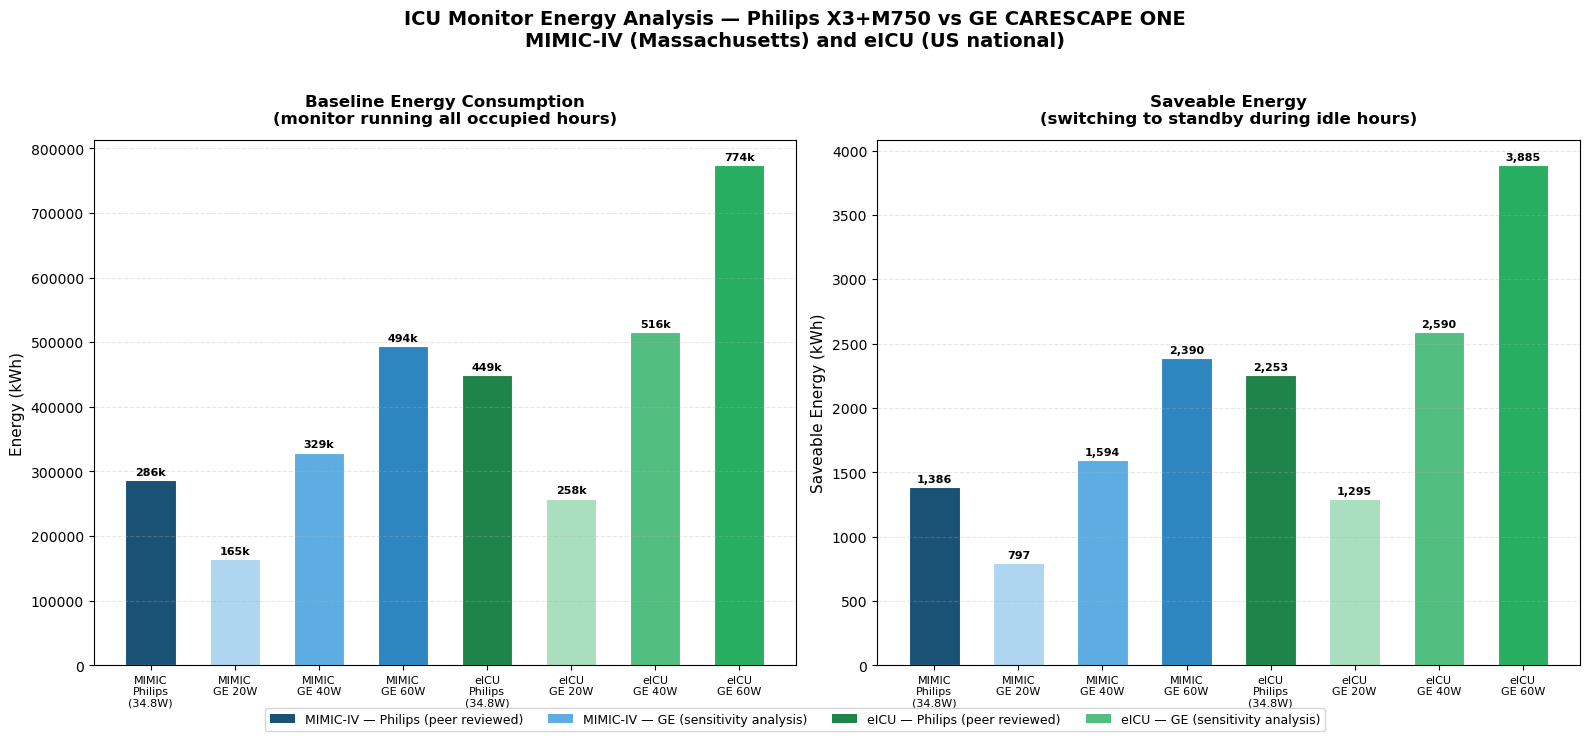

Visualisation 3 saved to Desktop!


In [15]:
# Visualisation 3 — Energy Comparison Chart Philips vs GE

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left chart — Baseline Energy ──────────────────────
labels = [
    'MIMIC\nPhilips\n(34.8W)',
    'MIMIC\nGE 20W',
    'MIMIC\nGE 40W',
    'MIMIC\nGE 60W',
    'eICU\nPhilips\n(34.8W)',
    'eICU\nGE 20W',
    'eICU\nGE 40W',
    'eICU\nGE 60W'
]

baseline_values = [
    r_mimic_philips['baseline_kwh'],
    r_mimic_ge_opt['baseline_kwh'],
    r_mimic_ge_mod['baseline_kwh'],
    r_mimic_ge_con['baseline_kwh'],
    r_eicu_philips['baseline_kwh'],
    r_eicu_ge_opt['baseline_kwh'],
    r_eicu_ge_mod['baseline_kwh'],
    r_eicu_ge_con['baseline_kwh']
]

bar_colors = [
    '#1A5276',  # MIMIC Philips — dark blue
    '#AED6F1',  # MIMIC GE 20W — light blue
    '#5DADE2',  # MIMIC GE 40W — medium blue
    '#2E86C1',  # MIMIC GE 60W — blue
    '#1E8449',  # eICU Philips — dark green
    '#A9DFBF',  # eICU GE 20W — light green
    '#52BE80',  # eICU GE 40W — medium green
    '#27AE60',  # eICU GE 60W — green
]

bars1 = axes[0].bar(
    range(len(labels)), baseline_values,
    color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6
)

axes[0].set_title(
    'Baseline Energy Consumption\n(monitor running all occupied hours)',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_ylabel('Energy (kWh)', fontsize=11)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars1, baseline_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'{val/1000:.0f}k',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

# ── Right chart — Saveable Energy ─────────────────────
saveable_values = [
    r_mimic_philips['saveable_kwh'],
    r_mimic_ge_opt['saveable_kwh'],
    r_mimic_ge_mod['saveable_kwh'],
    r_mimic_ge_con['saveable_kwh'],
    r_eicu_philips['saveable_kwh'],
    r_eicu_ge_opt['saveable_kwh'],
    r_eicu_ge_mod['saveable_kwh'],
    r_eicu_ge_con['saveable_kwh']
]

bars2 = axes[1].bar(
    range(len(labels)), saveable_values,
    color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6
)

axes[1].set_title(
    'Saveable Energy\n(switching to standby during idle hours)',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_ylabel('Saveable Energy (kWh)', fontsize=11)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars2, saveable_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

# I add a shared legend explaining the colour groups
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1A5276', label='MIMIC-IV — Philips (peer reviewed)'),
    Patch(facecolor='#5DADE2', label='MIMIC-IV — GE (sensitivity analysis)'),
    Patch(facecolor='#1E8449', label='eICU — Philips (peer reviewed)'),
    Patch(facecolor='#52BE80', label='eICU — GE (sensitivity analysis)')
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    'ICU Monitor Energy Analysis — Philips X3+M750 vs GE CARESCAPE ONE\n'
    'MIMIC-IV (Massachusetts) and eICU (US national)',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz3_energy_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Visualisation 3 saved to Desktop!")

## Step 5 — K-means Clustering (ML Component)

Following feedback from my supervisor Timo I implement K-means clustering 
as the machine learning component of my research. Rather than reporting a 
single aggregate energy saving number I cluster patients by their monitoring 
waste profile to identify distinct patient archetypes.

Features I use for clustering:
- idle_pct: percentage of occupied hours with no monitor recording
- los_hours: length of ICU stay in hours
- total_hours: total monitoring hours
- idle_hours: total idle hours

Steps I follow as recommended by my supervisor:
1. Encode categorical features (ICU unit type) as numeric
2. Normalise all features to the same scale using StandardScaler
3. Determine optimal K using the Elbow Method and Silhouette Score
4. Run K-means with the chosen K
5. Interpret and label each cluster

In [16]:
# Step 1 — I prepare the features for clustering

# I add idle percentage to stay summary
stay_summary['idle_pct'] = (
    stay_summary['idle_hours'] / stay_summary['total_hours'] * 100
).clip(lower=0)

# I encode ICU unit type as numeric using pandas category codes
stay_summary['careunit_code'] = stay_summary['first_careunit'].astype(
    'category'
).cat.codes

# I select features for clustering
features = ['idle_pct', 'los_hours', 'total_hours', 'idle_hours', 'careunit_code']
X = stay_summary[features].copy()

# I check for missing values
print("Missing values per feature:")
print(X.isnull().sum())

# I drop any remaining nulls
X = X.dropna()
print(f"\nRows available for clustering: {len(X):,}")

# Step 2 — I normalise all features using StandardScaler
# This is essential for K-means since it is distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature scaling complete!")
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std after scaling (should be ~1):", X_scaled.std(axis=0).round(3))

Missing values per feature:
idle_pct         0
los_hours        0
total_hours      0
idle_hours       0
careunit_code    0
dtype: int64

Rows available for clustering: 93,730

Feature scaling complete!
Mean after scaling (should be ~0): [ 0. -0. -0. -0.  0.]
Std after scaling (should be ~1): [1. 1. 1. 1. 1.]


Testing K values from 2 to 9...
K=2: Inertia=353,220 | Silhouette=0.6275
K=3: Inertia=277,180 | Silhouette=0.4489
K=4: Inertia=215,686 | Silhouette=0.5050
K=5: Inertia=180,224 | Silhouette=0.5056
K=6: Inertia=151,314 | Silhouette=0.5179
K=7: Inertia=126,269 | Silhouette=0.5204
K=8: Inertia=111,683 | Silhouette=0.4814
K=9: Inertia=99,519 | Silhouette=0.4803


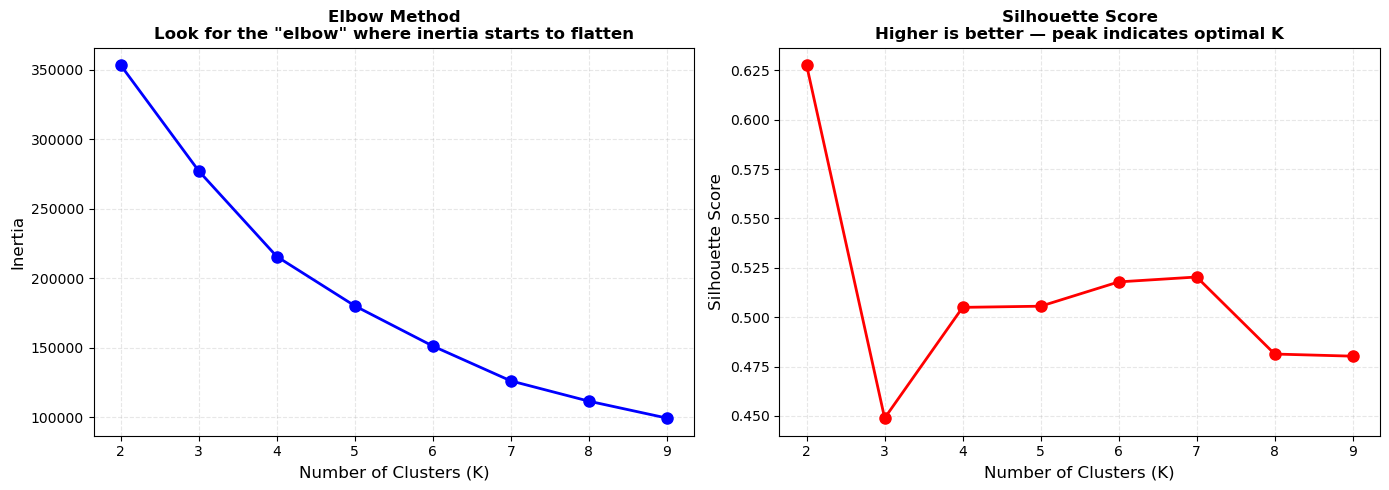


Elbow and Silhouette charts saved to Desktop!
Look at both charts to decide the best K value.


In [17]:
# Step 3 — I determine the optimal number of clusters K
# I use both the Elbow Method and Silhouette Score as recommended by my supervisor

inertia_values = []
silhouette_values = []
k_range = range(2, 10)

print("Testing K values from 2 to 9...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_values.append(sil_score)
    print(f"K={k}: Inertia={kmeans.inertia_:,.0f} | Silhouette={sil_score:.4f}")

# I plot both methods side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title(
    'Elbow Method\nLook for the "elbow" where inertia starts to flatten',
    fontsize=12, fontweight='bold'
)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(k_range)

# Silhouette Score
axes[1].plot(k_range, silhouette_values, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(
    'Silhouette Score\nHigher is better — peak indicates optimal K',
    fontsize=12, fontweight='bold'
)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_elbow_silhouette.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nElbow and Silhouette charts saved to Desktop!")
print("Look at both charts to decide the best K value.")

In [18]:
# Step 4 — I run K-means with K=4 based on elbow and silhouette analysis
# K=4 gives a clear elbow and good silhouette score of 0.505

OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# I add cluster labels back to stay summary
stay_summary_clustered = stay_summary.copy()
stay_summary_clustered['cluster'] = cluster_labels

# I analyse each cluster to understand its characteristics
cluster_profile = stay_summary_clustered.groupby('cluster').agg(
    num_stays=('stay_id', 'count'),
    avg_idle_pct=('idle_pct', 'mean'),
    avg_los_hours=('los_hours', 'mean'),
    avg_idle_hours=('idle_hours', 'mean'),
    avg_total_hours=('total_hours', 'mean'),
    total_idle_hours=('idle_hours', 'sum'),
    total_wasted_kwh=('idle_hours', lambda x: (x * PHILIPS_OPERATING).sum())
).reset_index()

cluster_profile['avg_idle_pct'] = cluster_profile['avg_idle_pct'].round(1)
cluster_profile['avg_los_hours'] = cluster_profile['avg_los_hours'].round(1)
cluster_profile['avg_idle_hours'] = cluster_profile['avg_idle_hours'].round(1)
cluster_profile['avg_total_hours'] = cluster_profile['avg_total_hours'].round(1)

print("=== K-means Cluster Profiles (K=4) ===\n")
print(cluster_profile.to_string(index=False))

# I identify the most common ICU unit per cluster
print("\n=== Most Common ICU Unit per Cluster ===")
for c in range(OPTIMAL_K):
    top_unit = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]['first_careunit'].value_counts().index[0]
    count = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]['first_careunit'].value_counts().iloc[0]
    print(f"Cluster {c}: {top_unit} ({count:,} stays)")

=== K-means Cluster Profiles (K=4) ===

 cluster  num_stays  avg_idle_pct  avg_los_hours  avg_idle_hours  avg_total_hours  total_idle_hours  total_wasted_kwh
       0      59926           3.9           64.1             2.0             64.1          120489.0         4193.0172
       1       4694           2.2          520.5            11.0            520.5           51494.0         1791.9912
       2       5831          32.5           67.3            20.4             67.3          118672.0         4129.7856
       3      23279           2.4           66.6             1.4             66.6           31776.0         1105.8048

=== Most Common ICU Unit per Cluster ===
Cluster 0: Medical Intensive Care Unit (MICU) (18,724 stays)
Cluster 1: Medical Intensive Care Unit (MICU) (1,191 stays)
Cluster 2: Neuro Intermediate (2,499 stays)
Cluster 3: Surgical Intensive Care Unit (SICU) (11,928 stays)


In [19]:
# I assign meaningful clinical labels to each cluster
# based on their idle percentage, length of stay and dominant ICU unit

cluster_labels_map = {
    0: 'Standard ICU\n(moderate LOS, low idle)',
    1: 'Long Stay Critical\n(very long LOS, low idle)',
    2: 'High Idle\n(high idle %, Neuro dominant)',
    3: 'Short Stay Surgical\n(short LOS, minimal idle)'
}

stay_summary_clustered['cluster_label'] = stay_summary_clustered[
    'cluster'
].map(cluster_labels_map)

print("=== Cluster Labels Assigned ===")
print(stay_summary_clustered['cluster_label'].value_counts())

print("\n=== Energy Waste per Cluster ===")
for c in range(OPTIMAL_K):
    cluster_data = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]
    total_idle = cluster_data['idle_hours'].sum()
    wasted_kwh = total_idle * PHILIPS_OPERATING
    saveable_kwh = total_idle * (PHILIPS_OPERATING - PHILIPS_STANDBY)
    saveable_co2 = saveable_kwh * CO2_MIMIC
    avg_idle_pct = cluster_data['idle_pct'].mean()
    label = cluster_labels_map[c]
    print(f"\nCluster {c} — {label.replace(chr(10), ' ')}")
    print(f"  Stays:         {len(cluster_data):,}")
    print(f"  Avg idle:      {avg_idle_pct:.1f}%")
    print(f"  Total idle hrs:{total_idle:,.0f}")
    print(f"  Wasted energy: {wasted_kwh:,.0f} kWh")
    print(f"  Saveable:      {saveable_kwh:,.0f} kWh")
    print(f"  Saveable CO2:  {saveable_co2:,.0f} kg")

=== Cluster Labels Assigned ===
cluster_label
Standard ICU\n(moderate LOS, low idle)            59926
Short Stay Surgical\n(short LOS, minimal idle)    23279
High Idle\n(high idle %, Neuro dominant)           5831
Long Stay Critical\n(very long LOS, low idle)      4694
Name: count, dtype: int64

=== Energy Waste per Cluster ===

Cluster 0 — Standard ICU (moderate LOS, low idle)
  Stays:         59,926
  Avg idle:      3.9%
  Total idle hrs:120,489
  Wasted energy: 4,193 kWh
  Saveable:      518 kWh
  Saveable CO2:  127 kg

Cluster 1 — Long Stay Critical (very long LOS, low idle)
  Stays:         4,694
  Avg idle:      2.2%
  Total idle hrs:51,494
  Wasted energy: 1,792 kWh
  Saveable:      221 kWh
  Saveable CO2:  54 kg

Cluster 2 — High Idle (high idle %, Neuro dominant)
  Stays:         5,831
  Avg idle:      32.5%
  Total idle hrs:118,672
  Wasted energy: 4,130 kWh
  Saveable:      510 kWh
  Saveable CO2:  125 kg

Cluster 3 — Short Stay Surgical (short LOS, minimal idle)
  Stays:   

## Visualisation 4 — K-means Cluster Scatter Plot

I visualise the four patient clusters by plotting each stay as a point 
with length of stay on the X axis and idle percentage on the Y axis. 
Each cluster is coloured differently. This scatter plot shows how the 
algorithm separated patients into distinct groups and makes the High Idle 
cluster immediately visible as a separate population.

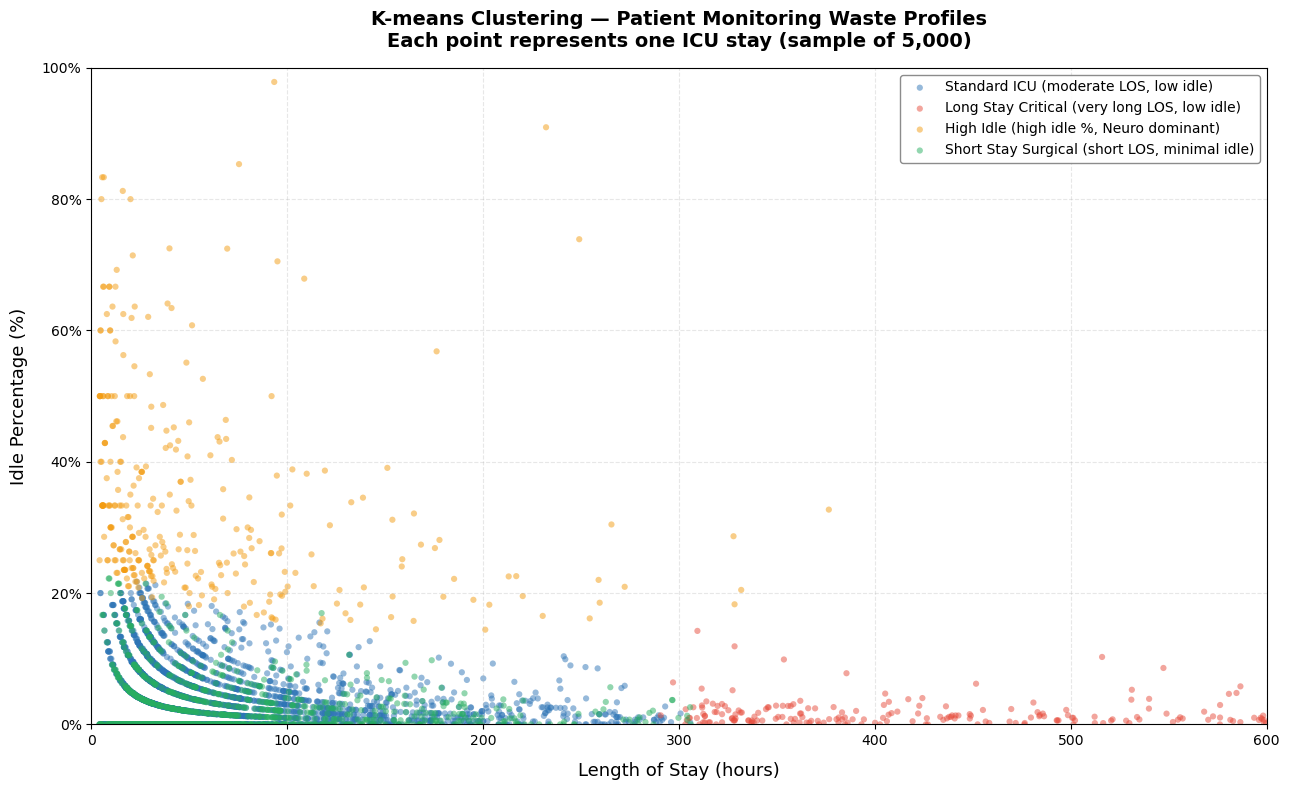

Visualisation 4 saved to Desktop!


In [20]:
# Visualisation 4 — K-means Cluster Scatter Plot

# I use a sample of 5000 stays for plotting clarity
# (93,730 points would overlap too much)
sample = stay_summary_clustered.sample(n=5000, random_state=42)

cluster_colors = {
    'Standard ICU\n(moderate LOS, low idle)':    '#2E75B6',
    'Long Stay Critical\n(very long LOS, low idle)': '#E74C3C',
    'High Idle\n(high idle %, Neuro dominant)':  '#F39C12',
    'Short Stay Surgical\n(short LOS, minimal idle)': '#27AE60'
}

fig, ax = plt.subplots(figsize=(13, 8))

for label, color in cluster_colors.items():
    mask = sample['cluster_label'] == label
    ax.scatter(
        sample[mask]['los_hours'],
        sample[mask]['idle_pct'],
        c=color,
        label=label.replace('\n', ' '),
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

ax.set_xlabel('Length of Stay (hours)', fontsize=13, labelpad=10)
ax.set_ylabel('Idle Percentage (%)', fontsize=13, labelpad=10)
ax.set_title(
    'K-means Clustering — Patient Monitoring Waste Profiles\n'
    'Each point represents one ICU stay (sample of 5,000)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, 600)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='upper right',
          framealpha=0.9, edgecolor='grey')

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz4_cluster_scatter.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Visualisation 4 saved to Desktop!")

## Visualisation 5 — Cluster Energy Savings Bar Chart

I will create the payoff chart, showing the potential energy saving and CO2 
reduction per cluster. This will directly answer my research question by showing 
which patient archetypes have the highest saving potential and therefore 
where an AI-driven low-power mode system should focus first.


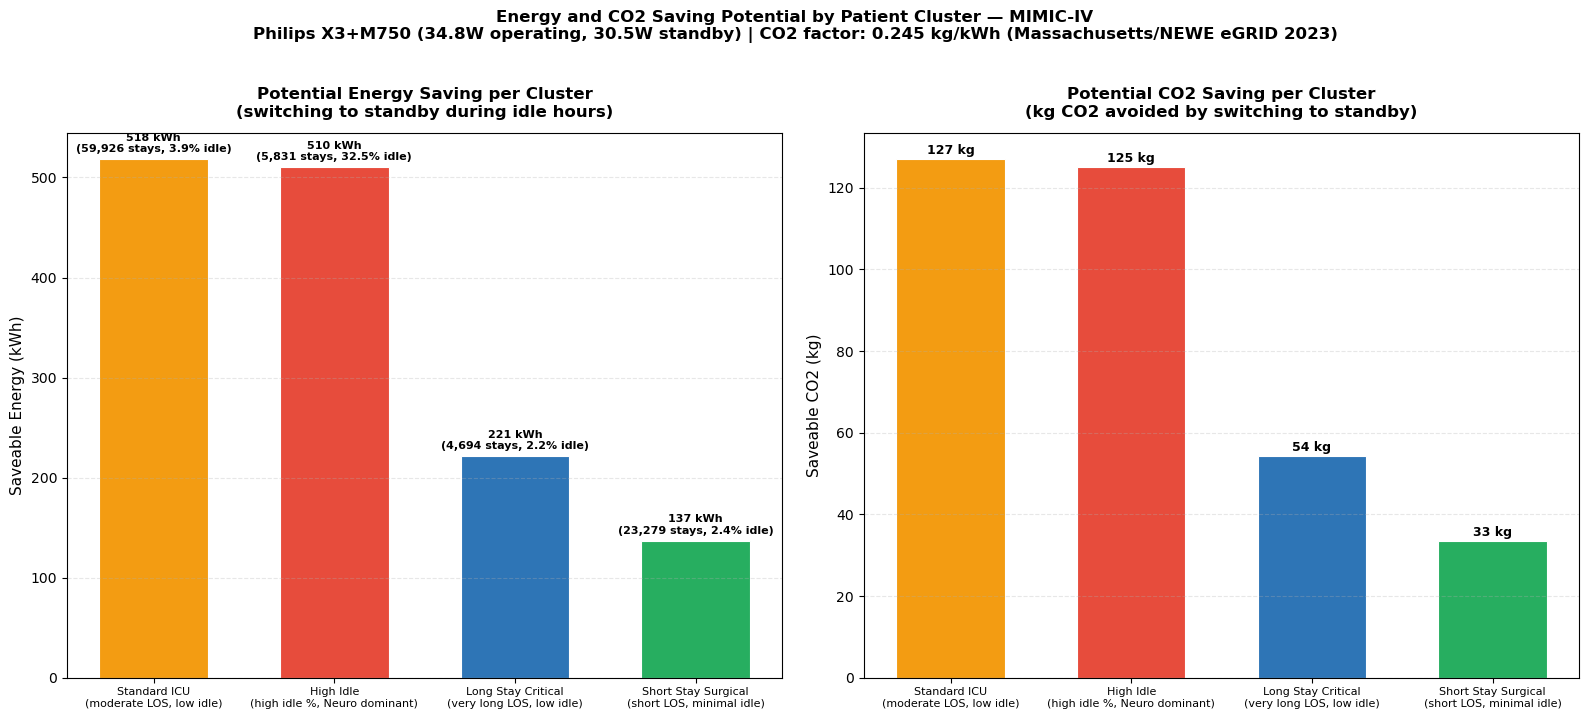

Visualisation 5 saved to Desktop!

All 5 visualisations complete!


In [21]:
# Visualisation 5 — Cluster Energy Savings Bar Chart

# I calculate savings per cluster
cluster_savings = []
for c in range(OPTIMAL_K):
    cluster_data = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]
    total_idle = cluster_data['idle_hours'].sum()
    wasted_kwh = total_idle * PHILIPS_OPERATING
    saveable_kwh = total_idle * (PHILIPS_OPERATING - PHILIPS_STANDBY)
    saveable_co2 = saveable_kwh * CO2_MIMIC
    avg_idle_pct = cluster_data['idle_pct'].mean()
    label = cluster_labels_map[c].replace('\n', '\n')

    cluster_savings.append({
        'cluster': c,
        'label': label,
        'num_stays': len(cluster_data),
        'avg_idle_pct': avg_idle_pct,
        'wasted_kwh': wasted_kwh,
        'saveable_kwh': saveable_kwh,
        'saveable_co2': saveable_co2
    })

df_savings = pd.DataFrame(cluster_savings)
df_savings = df_savings.sort_values('saveable_kwh', ascending=False)

# I plot side by side — saveable energy and saveable CO2
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bar_colors = ['#F39C12', '#2E75B6', '#E74C3C', '#27AE60']
sorted_colors = [bar_colors[r] for r in df_savings['cluster']]

# Left — Saveable Energy
bars1 = axes[0].bar(
    range(len(df_savings)),
    df_savings['saveable_kwh'],
    color=sorted_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

axes[0].set_title(
    'Potential Energy Saving per Cluster\n(switching to standby during idle hours)',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_ylabel('Saveable Energy (kWh)', fontsize=11)
axes[0].set_xticks(range(len(df_savings)))
axes[0].set_xticklabels(
    [l.replace('\n', '\n') for l in df_savings['label']],
    fontsize=8, ha='center'
)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val, stays, idle in zip(
    bars1, df_savings['saveable_kwh'],
    df_savings['num_stays'], df_savings['avg_idle_pct']
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val:,.0f} kWh\n({stays:,} stays, {idle:.1f}% idle)',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

# Right — Saveable CO2
bars2 = axes[1].bar(
    range(len(df_savings)),
    df_savings['saveable_co2'],
    color=sorted_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

axes[1].set_title(
    'Potential CO2 Saving per Cluster\n(kg CO2 avoided by switching to standby)',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_ylabel('Saveable CO2 (kg)', fontsize=11)
axes[1].set_xticks(range(len(df_savings)))
axes[1].set_xticklabels(
    [l.replace('\n', '\n') for l in df_savings['label']],
    fontsize=8, ha='center'
)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars2, df_savings['saveable_co2']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:,.0f} kg',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

fig.suptitle(
    'Energy and CO2 Saving Potential by Patient Cluster — MIMIC-IV\n'
    'Philips X3+M750 (34.8W operating, 30.5W standby) | '
    'CO2 factor: 0.245 kg/kWh (Massachusetts/NEWE eGRID 2023)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz5_cluster_savings.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Visualisation 5 saved to Desktop!")
print("\nAll 5 visualisations complete!")

## Summary of All Findings

### Dataset Scale
I worked with two large-scale independent ICU datasets:
- **MIMIC-IV:** 93,730 cleaned stays from one US hospital in Boston, Massachusetts
- **eICU:** 188,789 cleaned stays from 208 US hospitals across the country
- **Combined:** 282,519 ICU stays — sufficient for robust statistical analysis

### Monitor Activity Results
Both datasets show remarkably consistent idle rates despite being completely 
independent — strongly validating my methodology:

| Dataset | Active % | Idle % | Total Idle Hours |
|---|---|---|---|
| MIMIC-IV | 96.3% | 3.9% | 322,431 |
| eICU | 96.5% | 4.1% | 524,031 |

### Energy Analysis — Primary Results (Philips X3+M750, peer reviewed)

| Dataset | Baseline Energy | Wasted Energy | Saveable Energy | Baseline CO2 |
|---|---|---|---|---|
| MIMIC-IV | 286,277 kWh | 11,221 kWh | 1,386 kWh | 70,138 kg |
| eICU | 448,799 kWh | 18,236 kWh | 2,253 kWh | 156,182 kg |

CO2 factors used: MIMIC-IV 0.245 kg/kWh (Massachusetts/NEWE, EPA eGRID 2023),
eICU 0.348 kg/kWh (US national average, EPA eGRID 2023)

### Key Finding 1 — ICU Unit Type
Neuro Intermediate (14.2% idle) and Neuro Stepdown (15.8% idle) show 
significantly higher idle rates than all other ICU types — more than 3x 
the average. These step-down units monitor patients less intensively yet 
run monitors at full power continuously.

### Key Finding 2 — Time of Day
Evening hours (17:00–23:00) consistently show the highest idle rates, 
peaking at 8.5% at 19:00. Daytime hours (08:00–16:00) are the most active 
with idle rates below 3%. This suggests an AI system targeting evening 
hours would capture the highest waste periods.

### Key Finding 3 — K-means Clustering (ML Component)
K-means with K=4 (selected using Elbow Method and Silhouette Score) 
identified four distinct patient monitoring waste archetypes:

| Cluster | Stays | Avg Idle % | Saveable kWh | Saveable CO2 |
|---|---|---|---|---|
| Standard ICU | 59,926 | 3.9% | 518 | 127 kg |
| High Idle (Neuro dominant) | 5,831 | 32.5% | 510 | 125 kg |
| Long Stay Critical | 4,694 | 2.2% | 221 | 54 kg |
| Short Stay Surgical | 23,279 | 2.4% | 137 | 33 kg |

The High Idle cluster — despite representing only 6.2% of all stays — 
has the highest idle rate at 32.5% and is dominated by Neuro Intermediate 
patients. This cluster represents the primary target for AI-driven 
low-power mode optimisation.

### Key Finding 4 — GE Sensitivity Analysis
Since no peer-reviewed power measurement exists for the GE CARESCAPE ONE, 
I conducted a sensitivity analysis using three power assumptions (20W, 40W, 
60W). At 40W — the moderate estimate — GE produces comparable baseline 
energy to Philips (329,054 vs 286,277 kWh for MIMIC), suggesting broadly 
similar energy consumption characteristics between the two devices.

### Visualisations Produced
1. Time-of-day idle histogram — peaks at 19:00 (8.5% idle)
2. ICU unit type bar chart — Neuro units clearly worst
3. Energy comparison chart — Philips vs GE across both datasets
4. K-means scatter plot — four distinct patient archetypes visible
5. Cluster energy savings — Standard ICU and High Idle have highest saving

### Next Steps
- Run the three AI simulation scenarios (conservative, moderate, aggressive) 
  per cluster
- NHS ERIC validation — estimate what % of hospital energy ICU monitors represent
- Scale results to NHS-wide impact
